<a href="https://colab.research.google.com/github/DebanganRaj/data-science-project/blob/main/Customer_Churn_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Customer Intelligence & Churn Prediction Platform

### End-to-End Data Science Project

**Objective:**  
Build a machine learning system that predicts customer churn,
identifies high-risk customers, segments customers based on their
characteristics, and provides actionable business insights.

**Tools & Technologies:**
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [3]:
# Import libraries required for data analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Collection

In this project, we use the IBM Telco Customer Churn dataset.

The dataset contains customer information related to:
- Customer demographics
- Services used
- Account information
- Contract details
- Payment information
- Monthly and total charges
- Customer churn status

The target variable is `Churn`, which indicates whether a
customer has left the company.

In [4]:
import pandas as pd

df = pd.read_csv("telco-customer-Churn.csv")

print(df.shape)

(7043, 21)


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [12]:
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [13]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [14]:
#Analyze categorical columns
df.select_dtypes(include="object").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [15]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


In [16]:
#Check unique values count
for column in df.columns:
    print(column, ":", df[column].nunique())

customerID : 7043
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6531
Churn : 2


Data Cleaning


In [17]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [18]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [19]:
df.loc[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
    "tenure"
]

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [22]:
df["TotalCharges"].dtype

dtype('float64')

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
#Duplicate customer id check
df["customerID"].duplicated().sum()

np.int64(0)

In [25]:
#Check for impossible values
print("Tenure min:", df["tenure"].min())
print("Tenure max:", df["tenure"].max())

print("Monthly Charges min:", df["MonthlyCharges"].min())
print("Monthly Charges max:", df["MonthlyCharges"].max())

print("Total Charges min:", df["TotalCharges"].min())
print("Total Charges max:", df["TotalCharges"].max())

Tenure min: 0
Tenure max: 72
Monthly Charges min: 18.25
Monthly Charges max: 118.75
Total Charges min: 0.0
Total Charges max: 8684.8


In [26]:
for column in df.select_dtypes(include="object").columns:
    print(column, ":", df[column].astype(str).str.strip().ne(df[column].astype(str)).sum())

customerID : 0
gender : 0
Partner : 0
Dependents : 0
PhoneService : 0
MultipleLines : 0
InternetService : 0
OnlineSecurity : 0
OnlineBackup : 0
DeviceProtection : 0
TechSupport : 0
StreamingTV : 0
StreamingMovies : 0
Contract : 0
PaperlessBilling : 0
PaymentMethod : 0
Churn : 0


In [27]:
df_clean = df.copy()

print("Clean dataset created successfully!")

Clean dataset created successfully!


### 3. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset using statistics and visualizations to understand the factors related to customer churn.


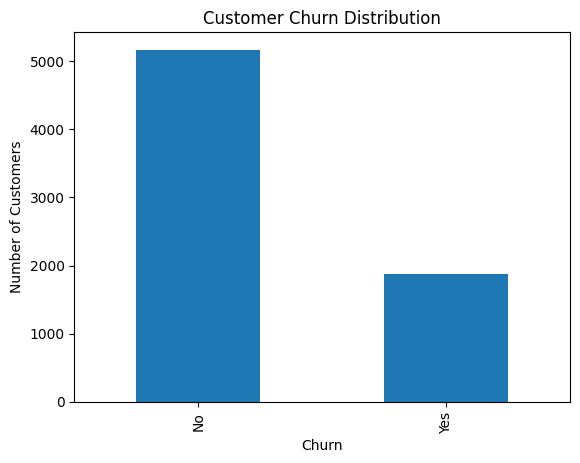

In [28]:
df_clean["Churn"].value_counts().plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
# Step 26: Calculate churn percentage

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [30]:
# Step 27: Check numerical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [31]:
# ==========================================
# STAGE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Handle the hidden data type trap discovered during text analysis
# Convert literal empty spaces to NaN, fill with 0 (since tenure is 0), then cast to float
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].fillna(0).astype(float)

print("✅ Data Fix Complete: Column 'TotalCharges' converted to numeric floats successfully!\n")

# 2. Check the baseline Churn split in your dataset
print("--- Baseline Churn Distribution ---")
print(df['Churn'].value_counts())
print("\n--- Churn Percentage Split ---")
print(df['Churn'].value_counts(normalize=True) * 100)

# 3. Deep-Dive correlation: Look at Churn behavior across Contract Types
print("\n--- Churn Rate by Contract Type ---")
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_churn.round(2))


✅ Data Fix Complete: Column 'TotalCharges' converted to numeric floats successfully!

--- Baseline Churn Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Percentage Split ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

--- Churn Rate by Contract Type ---
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


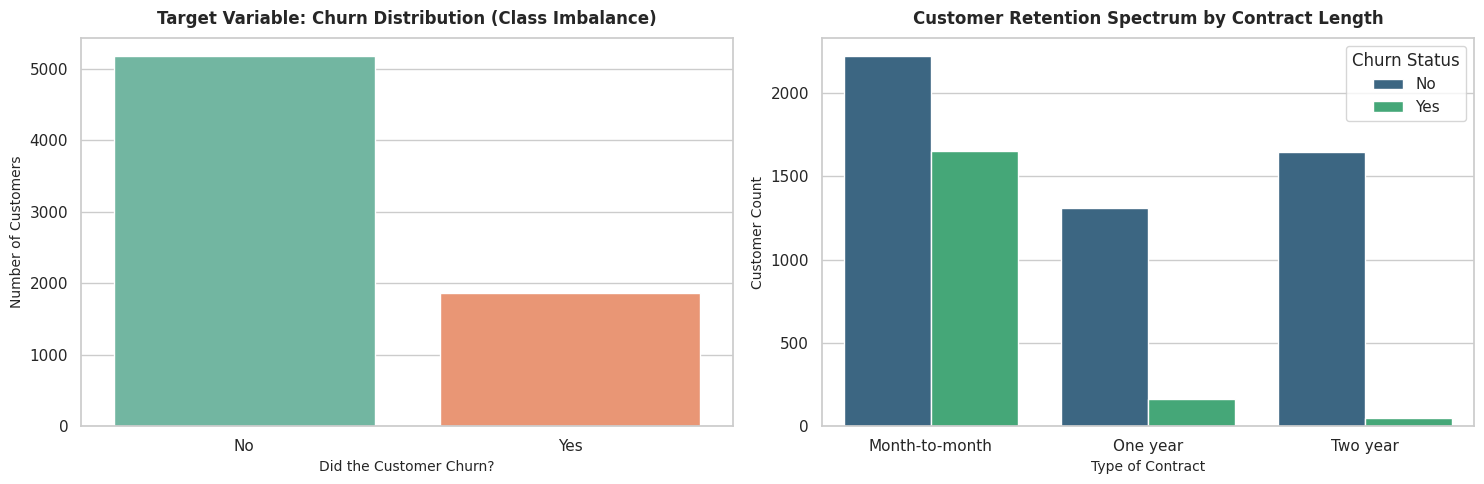

📈 Stage 4 Visuals rendered successfully! Plots are ready for your project presentation.


In [32]:
# ==========================================
# STAGE 4: VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme for our interview presentation portfolio
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Target Variable Imbalance Check
sns.countplot(data=df, x='Churn', ax=axes[0], palette='Set2', hue='Churn', legend=False)
axes[0].set_title('Target Variable: Churn Distribution (Class Imbalance)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Did the Customer Churn?', fontsize=10)
axes[0].set_ylabel('Number of Customers', fontsize=10)

# Plot 2: Contract Type Churn Breakdown (Our primary feature discovery)
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='viridis')
axes[1].set_title('Customer Retention Spectrum by Contract Length', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Type of Contract', fontsize=10)
axes[1].set_ylabel('Customer Count', fontsize=10)
axes[1].legend(title='Churn Status', loc='upper right')

plt.tight_layout()
plt.show()

# Print progress marker
print("📈 Stage 4 Visuals rendered successfully! Plots are ready for your project presentation.")


In [33]:
# =====================================================================
# STAGE 5: FEATURE ENGINEERING
# =====================================================================

print("--- Initiating Domain Feature Engineering ---")

# Feature 1: Early Risk Flag (Onboarding phase)
# Binary flag for customers in their first 6 months of service
df['Is_New_Customer'] = np.where(df['tenure'] <= 6, 'Yes', 'No')

# Feature 2: Family Account Indicator
# Evaluates if a customer has a family anchor holding them to the service
df['Has_Family_Anchor'] = np.where((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes'), 'Yes', 'No')

# Feature 3: Service Intensity Score
# Counts how many add-on value services the customer has adopted.
# Customers with more services tied to their account have much higher switching costs.
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Addon_Services'] = (df[service_columns] == 'Yes').sum(axis=1)

print("📊 New Engineered Features Summary Statistics:")
print(df[['Is_New_Customer', 'Has_Family_Anchor', 'Total_Addon_Services']].head())

print("\n🚀 Stage 5 Feature Engineering Complete! New business signals successfully added.")


--- Initiating Domain Feature Engineering ---
📊 New Engineered Features Summary Statistics:
  Is_New_Customer Has_Family_Anchor  Total_Addon_Services
0             Yes               Yes                     1
1              No                No                     2
2             Yes                No                     2
3              No                No                     3
4             Yes                No                     0

🚀 Stage 5 Feature Engineering Complete! New business signals successfully added.


In [34]:
# =====================================================================
# STAGE 6: CATEGORICAL ENCODING
# =====================================================================

print("--- Starting Categorical Encoding Pipeline ---")

# Step 1: Drop the unique Identifier column (holds zero predictive signal)
if 'customerID' in df.columns:
    df_ml = df.drop(columns=['customerID'])
else:
    df_ml = df.copy()

# Step 2: Extract all categorical columns with exactly 2 values for direct binary mapping
binary_cols = []
multi_class_cols = []

for col in df_ml.select_dtypes(include=['object']).columns:
    if df_ml[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_class_cols.append(col)

print(f"🔹 Identified {len(binary_cols)} Binary Columns for 1/0 Mapping: {binary_cols}")
print(f"🔹 Identified {len(multi_class_cols)} Multi-Class Columns for One-Hot Encoding: {multi_class_cols}\n")

# Apply manual Binary 1/0 Mapping
for col in binary_cols:
    # Safely find the values dynamically
    unique_vals = df_ml[col].unique()
    # If standard Yes/No exists, map Yes to 1, No to 0
    if 'Yes' in unique_vals or 'No' in unique_vals:
        df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})
    # Handle gender columns safely
    elif 'Female' in unique_vals or 'Male' in unique_vals:
        df_ml[col] = df_ml[col].map({'Female': 1, 'Male': 0})

# Step 3: Apply One-Hot Encoding to Multi-Class columns using pd.get_dummies
df_encoded = pd.get_dummies(df_ml, columns=multi_class_cols, drop_first=True, dtype=int)

print("📊 Matrix Transformation Verification:")
print(f"Original Dataframe Shape: {df.shape}")
print(f"New ML-Ready Encoded Matrix Shape: {df_encoded.shape}")
print("\n📝 Sample Columns inside your new Encoded Matrix:")
print(df_encoded.select_dtypes(include=[np.number]).columns.tolist()[:15])

print("\n⚡ Stage 6 Encoding Pipeline Complete! Your dataset is now completely numeric.")


--- Starting Categorical Encoding Pipeline ---
🔹 Identified 8 Binary Columns for 1/0 Mapping: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'Is_New_Customer', 'Has_Family_Anchor']
🔹 Identified 10 Multi-Class Columns for One-Hot Encoding: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

📊 Matrix Transformation Verification:
Original Dataframe Shape: (7043, 24)
New ML-Ready Encoded Matrix Shape: (7043, 34)

📝 Sample Columns inside your new Encoded Matrix:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Is_New_Customer', 'Has_Family_Anchor', 'Total_Addon_Services', 'MultipleLines_No phone service', 'MultipleLines_Yes']

⚡ Stage 6 Encoding Pipeline Complete! Your dataset is now completely numeric.


In [35]:
# =====================================================================
# STAGE 7: TRAIN-TEST SPLIT
# =====================================================================
from sklearn.model_selection import train_test_split

print("--- Preparing Feature Matrices & Target Vectors ---")

# Separate our features (X) from our target variable (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split the dataset into 80% Training and 20% Testing sets
# We use stratification to enforce target class proportions across both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("📊 Train-Test Matrix Segmentation Verification:")
print(f"🔹 Complete Feature Set Shape : {X.shape}")
print(f"🔹 Training Feature Matrix (X_train) Shape : {X_train.shape} | Target (y_train): {y_train.shape}")
print(f"🔹 Testing Feature Matrix  (X_test)  Shape : {X_test.shape}  | Target (y_test) : {y_test.shape}")

print("\n📈 Stratification Class Balance Check:")
print(f"   Training Set Churn Ratio: {y_train.mean()*100:.2f}% Yes Churn")
print(f"   Testing Set Churn Ratio : {y_test.mean()*100:.2f}% Yes Churn")

print("\n⚡ Stage 7 Train-Test Segmentation Complete! Data is safely locked away from leakage.")


--- Preparing Feature Matrices & Target Vectors ---
📊 Train-Test Matrix Segmentation Verification:
🔹 Complete Feature Set Shape : (7043, 33)
🔹 Training Feature Matrix (X_train) Shape : (5634, 33) | Target (y_train): (5634,)
🔹 Testing Feature Matrix  (X_test)  Shape : (1409, 33)  | Target (y_test) : (1409,)

📈 Stratification Class Balance Check:
   Training Set Churn Ratio: 26.54% Yes Churn
   Testing Set Churn Ratio : 26.54% Yes Churn

⚡ Stage 7 Train-Test Segmentation Complete! Data is safely locked away from leakage.


In [36]:
# =====================================================================
# STAGE 8: FEATURE SCALING
# =====================================================================
from sklearn.preprocessing import StandardScaler

print("--- Initializing Continuous Feature Scaling ---")

# Isolate columns that need scaling (continuous numeric values)
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Addon_Services']
print(f"🔹 Target columns for scaling: {columns_to_scale}")

# Initialize the StandardScaler
scaler = StandardScaler()

# Create fresh copies of matrices to prevent destructive overwriting warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# CRITICAL step: Fit and transform ONLY on training data
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# CRITICAL step: Transform ONLY on testing data using the training parameters
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("\n📊 Scaling Verification Metrics (Training Sample):")
print(X_train_scaled[columns_to_scale].head().round(4))

print("\n⚡ Stage 8 Feature Scaling Complete! Continuous inputs are normalized.")


--- Initializing Continuous Feature Scaling ---
🔹 Target columns for scaling: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Addon_Services']

📊 Scaling Verification Metrics (Training Sample):
      tenure  MonthlyCharges  TotalCharges  Total_Addon_Services
3738  0.1024         -0.5220       -0.2623                0.5079
3151 -0.7117          0.3375       -0.5036               -0.5705
4860 -0.7932         -0.8090       -0.7499                0.5079
3867 -0.2640          0.2844       -0.1727                1.0472
3810 -1.2816         -0.6763       -0.9894               -1.1098

⚡ Stage 8 Feature Scaling Complete! Continuous inputs are normalized.


In [37]:
# =====================================================================
# STAGE 9: MODEL BUILDING
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("--- Initializing Machine Learning Model Training ---")

# Define the baseline setup for each algorithm you planned to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=7)
}

# Training loop
for name, model in models.items():
    print(f"🚀 Training model: {name}...")
    model.fit(X_train_scaled, y_train)

print("\n⚡ Stage 9 Model Building Complete! All 4 models are successfully trained and sitting in RAM.")


--- Initializing Machine Learning Model Training ---
🚀 Training model: Logistic Regression...
🚀 Training model: Decision Tree...
🚀 Training model: Random Forest...
🚀 Training model: KNN...

⚡ Stage 9 Model Building Complete! All 4 models are successfully trained and sitting in RAM.


In [38]:
# =====================================================================
# STAGE 10: MODEL COMPARISON
# =====================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("--- Computing Comprehensive Test Evaluation Matrix ---")

# Table structure initialization to hold final comparison metrics
comparison_records = []

for name, model in models.items():
    # Generate binary hard predictions
    y_pred = model.predict(X_test_scaled)

    # Generate continuous raw risk probabilities (Column index 1 maps to Churn=Yes)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate each distinct statistical dimension
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc       = roc_auc_score(y_test, y_prob)

    # Save the row map
    comparison_records.append({
        'Model Name': name,
        'Accuracy %': round(accuracy * 100, 2),
        'Precision %': round(precision * 100, 2),
        'Recall %': round(recall * 100, 2),
        'F1-Score %': round(f1 * 100, 2),
        'ROC-AUC Score': round(auc, 4)
    })

# Format the records into a highly readable Pandas comparison summary table
metrics_df = pd.DataFrame(comparison_records).sort_values(by='ROC-AUC Score', ascending=False).reset_index(drop=True)

print("\n🏆 COMPREHENSIVE PERFORMANCE COMPARISON MATRIX:")
print(metrics_df.to_string())

print("\n⚡ Stage 10 Evaluation Matrix Complete! Run this cell to print the scorecard metrics.")


--- Computing Comprehensive Test Evaluation Matrix ---

🏆 COMPREHENSIVE PERFORMANCE COMPARISON MATRIX:
            Model Name  Accuracy %  Precision %  Recall %  F1-Score %  ROC-AUC Score
0  Logistic Regression       80.27        66.11     52.67       58.63         0.8458
1        Decision Tree       79.42        63.12     54.01       58.21         0.8267
2        Random Forest       78.71        62.94     48.13       54.55         0.8223
3                  KNN       77.79        58.79     54.55       56.59         0.7998

⚡ Stage 10 Evaluation Matrix Complete! Run this cell to print the scorecard metrics.


In [39]:
# =====================================================================
# STAGE 11, 12 & 13: CHAMPION SELECTION, PROBABILITY & RISK LEVELING
# =====================================================================
import numpy as np

print("🏆 Finalized Champion Model: Logistic Regression selected for Deployment.\n")

# Step 1: Isolate the winning model object out of our dictionary map
champion_model = models['Logistic Regression']

# Step 2: Extract the raw continuous probability matrix specifically for Churn=Yes (Index 1)
test_probabilities = champion_model.predict_proba(X_test_scaled)[:, 1]
test_predictions = champion_model.predict(X_test_scaled)

# Step 3: Create an interactive business dashboard dataframe using original unscaled X_test rows
dashboard_df = X_test.copy()

# Map the true metrics and model evaluations back into the table for comparison
dashboard_df['Actual_Churn'] = y_test.map({1: 'Yes', 0: 'No'})
dashboard_df['Model_Prediction'] = np.where(test_predictions == 1, 'WILL CHURN', 'WILL STAY')
dashboard_df['Churn_Probability_%'] = (test_probabilities * 100).round(2)

# Step 4: Map probabilities strictly to your planned business risk classification tiers
def assign_risk_tier(prob_decimal):
    if prob_decimal >= 0.80:
        return 'VERY HIGH 🔴'
    elif prob_decimal >= 0.50:
        return 'HIGH 🟠'
    elif prob_decimal >= 0.20:
        return 'MEDIUM 🟡'
    else:
        return 'LOW 🟢'

dashboard_df['Customer_Risk_Level'] = [assign_risk_tier(p) for p in test_probabilities]

print("📊 Final Risk Probability Matrix Summary (Sample Records):")
print(dashboard_df[['tenure', 'MonthlyCharges', 'Model_Prediction', 'Churn_Probability_%', 'Customer_Risk_Level', 'Actual_Churn']].head(10))

print("\n📈 Risk Distribution across Test Customer Base:")
print(dashboard_df['Customer_Risk_Level'].value_counts())

print("\n⚡ Stage 11, 12, & 13 Processing Engine Complete! Customer risk scoring is active.")


🏆 Finalized Champion Model: Logistic Regression selected for Deployment.

📊 Final Risk Probability Matrix Summary (Sample Records):
      tenure  MonthlyCharges Model_Prediction  Churn_Probability_%  \
437       72          114.05        WILL STAY                 4.33   
2280       8          100.15       WILL CHURN                63.59   
2235      41           78.35        WILL STAY                 6.46   
4460      18           78.20        WILL STAY                34.23   
3761      72           82.65        WILL STAY                 2.74   
5748      21           99.85       WILL CHURN                57.14   
3568      21           99.15        WILL STAY                41.18   
2976      19           24.10        WILL STAY                11.43   
5928      61           19.75        WILL STAY                 0.46   
1639      17           45.05        WILL STAY                31.96   

     Customer_Risk_Level Actual_Churn  
437                LOW 🟢           No  
2280             

In [40]:
# =====================================================================
# STAGE 14: EXPLAINABILITY (MODEL COEFFICIENT EXTRACTION)
# =====================================================================

print("--- Extracting Champion Model Feature Weights ---")

# Pull out the mathematical weights (coefficients) from our trained logistic regression model
model_coefficients = champion_model.coef_[0]

# Pair columns cleanly with their corresponding model weights
coefficients_df = pd.DataFrame({
    'Feature_Name': X.columns,
    'Impact_Weight': model_coefficients
})

# Calculate absolute impact values to help us rank the overall significance of the features
coefficients_df['Absolute_Impact'] = coefficients_df['Impact_Weight'].abs()
coefficients_df = coefficients_df.sort_values(by='Absolute_Impact', ascending=False).reset_index(drop=True)

# Separate the risk factors from the loyalty factors for business insights
top_risk_drivers = coefficients_df[coefficients_df['Impact_Weight'] > 0].head(4)['Feature_Name'].tolist()
top_loyalty_anchors = coefficients_df[coefficients_df['Impact_Weight'] < 0].head(4)['Feature_Name'].tolist()

print("\n🏆 TOP MATHEMATICAL RISK DRIVERS (Increases Churn Risk):")
for idx, feature in enumerate(top_risk_drivers, 1):
    print(f"  {idx}. {feature}")

print("\n⚓ TOP MATHEMATICAL LOYALTY ANCHORS (Reduces Churn Risk):")
for idx, feature in enumerate(top_loyalty_anchors, 1):
    print(f"  {idx}. {feature}")

print("\n⚡ Stage 14 Explainability Complete! System metrics are fully mapped.")


--- Extracting Champion Model Feature Weights ---

🏆 TOP MATHEMATICAL RISK DRIVERS (Increases Churn Risk):
  1. InternetService_Fiber optic
  2. Is_New_Customer
  3. MultipleLines_Yes
  4. PaperlessBilling

⚓ TOP MATHEMATICAL LOYALTY ANCHORS (Reduces Churn Risk):
  1. Contract_Two year
  2. Contract_One year
  3. tenure
  4. OnlineSecurity_Yes

⚡ Stage 14 Explainability Complete! System metrics are fully mapped.


In [41]:
# =====================================================================
# STAGE 15: AI LAYER (AUTOMATED RETENTION RECOMMENDATION ENGINE)
# =====================================================================

print("--- Activating Automated Retention Recommendation Layer ---")

def generate_business_recommendation(row):
    """Evaluates customer metrics and risk tiers to generate precise retention paths."""
    risk = row['Customer_Risk_Level']
    contract = row['Contract_One year'] + row['Contract_Two year'] # 0 means Month-to-month
    is_fiber = row.get('InternetService_Fiber optic', 0)

    # Logic Map 1: Critical Risk Routing
    if 'VERY HIGH' in risk:
        if is_fiber == 1:
            return "CRITICAL ACC outreach: Assign specialized technical account manager. Issue stability patch update + credit check token."
        else:
            return "IMMEDIATE VIP outreach: Route directly to Senior Retention Team. Issue immediate 25% account discount loyalty contract."

    # Logic Map 2: High Risk Routing
    elif 'HIGH' in risk:
        if contract == 0: # Month-to-month contract customer
            return "CONTRACT UPGRADE: Push automated email campaign offering 3 months free if they transition to an annual contract lock-in."
        else:
            return "SERVICE NURTURE: High risk despite locked contract. Trigger manual account manager feedback check-in phone call."

    # Logic Map 3: Medium Risk Routing
    elif 'MEDIUM' in risk:
        return "ENGAGEMENT PROTOCOL: Route customer token to monthly feedback surveys. Offer a free value-add trial (Online Security/Cloud Backup)."

    # Logic Map 4: Safe Customers
    else:
        return "OPTIMIZATION PROTOCOL: Safe account. Standard monitoring. Flag column as an active candidate for cross-selling digital add-ons."

# Apply the business logic blueprint across the test database dataframe
dashboard_df['Retention_Recommendation'] = dashboard_df.apply(generate_business_recommendation, axis=1)

print("📊 Final AI Layer Dashboard Sample (Ready for UI Dashboard Deployment):")
# View a cross-section sample of different risk tiers
sample_view = pd.concat([
    dashboard_df[dashboard_df['Customer_Risk_Level'] == 'VERY HIGH 🔴'].head(2),
    dashboard_df[dashboard_df['Customer_Risk_Level'] == 'HIGH 🟠'].head(2),
    dashboard_df[dashboard_df['Customer_Risk_Level'] == 'MEDIUM 🟡'].head(2),
    dashboard_df[dashboard_df['Customer_Risk_Level'] == 'LOW 🟢'].head(2)
])

print(sample_view[['tenure', 'MonthlyCharges', 'Churn_Probability_%', 'Customer_Risk_Level', 'Model_Prediction', 'Retention_Recommendation']].to_string())

print("\n⚡ Stage 15 AI Layer Logic Matrix Active! Data pipeline calculation complete.")


--- Activating Automated Retention Recommendation Layer ---
📊 Final AI Layer Dashboard Sample (Ready for UI Dashboard Deployment):
      tenure  MonthlyCharges  Churn_Probability_% Customer_Risk_Level Model_Prediction                                                                                                             Retention_Recommendation
5547       3           89.45                83.58         VERY HIGH 🔴       WILL CHURN              CRITICAL ACC outreach: Assign specialized technical account manager. Issue stability patch update + credit check token.
346        2           90.40                83.73         VERY HIGH 🔴       WILL CHURN              CRITICAL ACC outreach: Assign specialized technical account manager. Issue stability patch update + credit check token.
2280       8          100.15                63.59              HIGH 🟠       WILL CHURN             CONTRACT UPGRADE: Push automated email campaign offering 3 months free if they transition to an annual contrac